In [16]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if not torch.cuda.is_available():
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device: %s" % device)

Using device: cpu


In [17]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 209kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.89MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.2MB/s]


In [18]:
# 1st model
model1 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

# 2nd model
model2 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 48),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(48, 10)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer1 = optim.SGD(model1.parameters(), lr=0.1)
optimizer2 = optim.SGD(model2.parameters(), lr=0.1, weight_decay=0.0001)

In [20]:
def train_model(model, optimizer, num_epochs=40):
    for epoch in range(num_epochs):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    num_correct = 0
    num_samples = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            num_samples += labels.size(0)
            num_correct += (predicted == labels).sum().item()
    print("Final Test Acc: %.2f%%" % (100 * num_correct / num_samples))

print("Model 1 (no reg, no drop)")
train_model(model1, optimizer1, 40)

print("\n Model 2:")
train_model(model2, optimizer2, 40)

Model 1 (no reg, no drop)
Final Test Acc: 89.17%

 Model 2:
Final Test Acc: 88.19%


Histigram for model 1

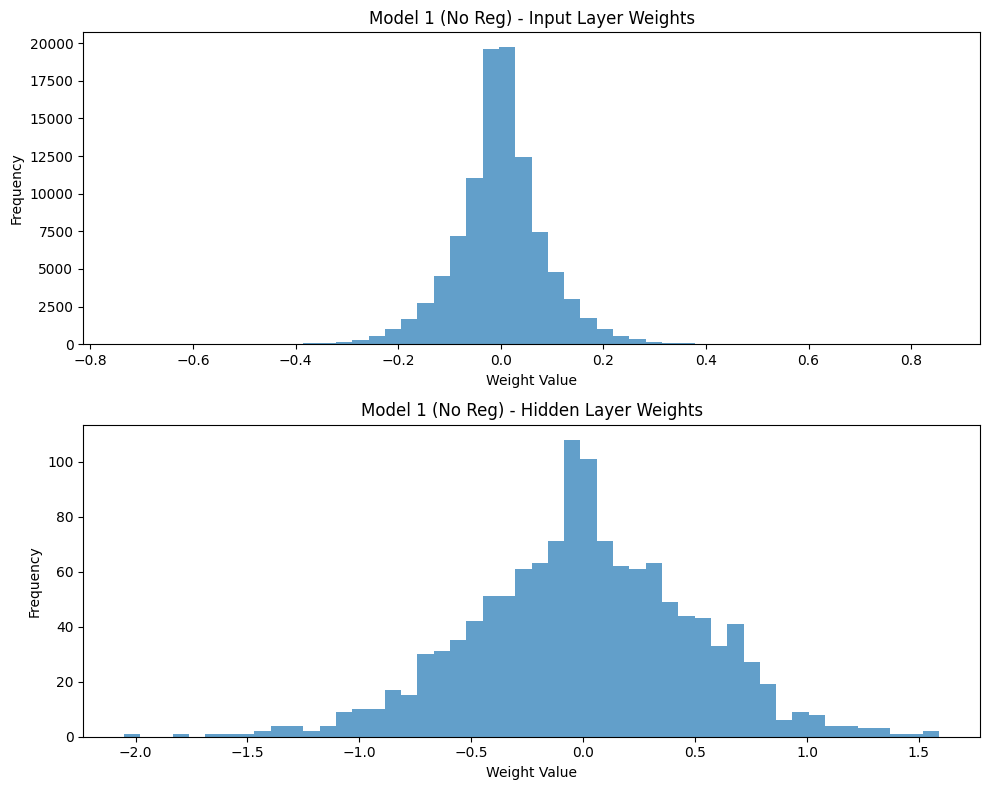

In [24]:
weights1 = []
for name, param in model1.named_parameters():
    if "weight" in name:
        weights1.append(param.data.cpu().numpy().flatten())

layer_labels = ["Input Layer", "Hidden Layer"]
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
for i in range(2):
    axes[i].hist(weights1[i], bins=50, alpha=0.7)
    axes[i].set_title("Model 1 (No Reg) - %s Weights" % layer_labels[i])
    axes[i].set_xlabel("Weight Value")
    axes[i].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

Histigram for model 1

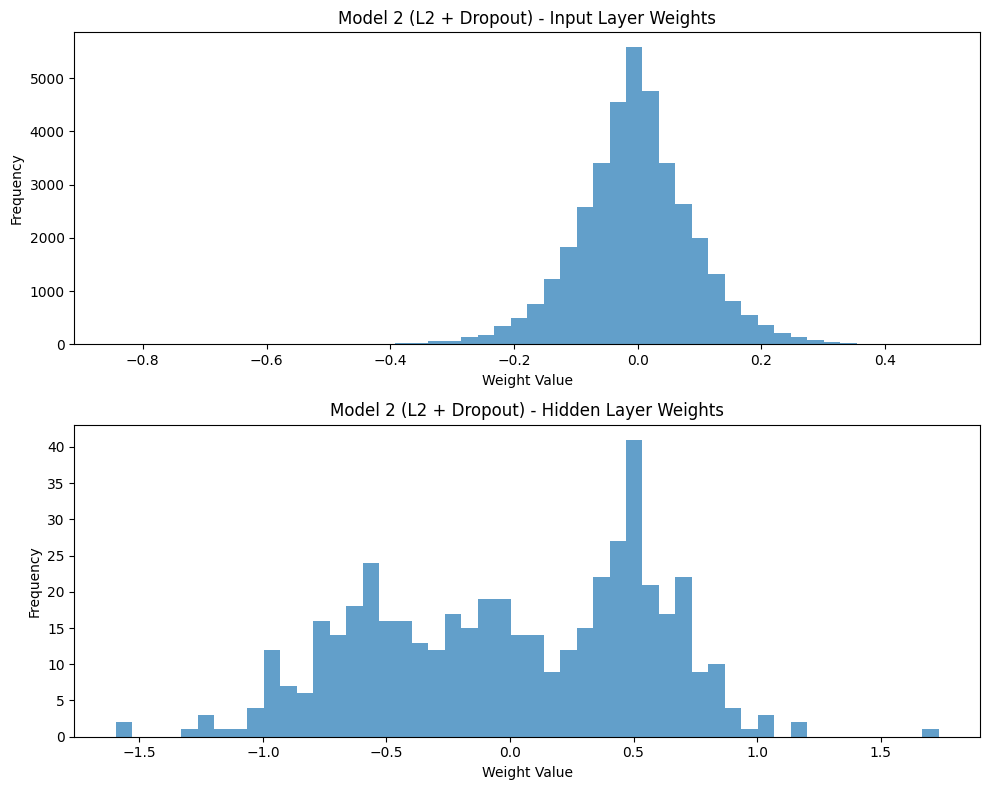

In [25]:
weights2 = []
for name, param in model2.named_parameters():
    if "weight" in name:
        weights2.append(param.data.cpu().numpy().flatten())

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
for i in range(2):
    axes[i].hist(weights2[i], bins=50, alpha=0.7)
    axes[i].set_title("Model 2 (L2 + Dropout) - %s Weights" % layer_labels[i])
    axes[i].set_xlabel("Weight Value")
    axes[i].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

Qualitative difference - Model 1's input layer peaks at 0 within mainly -0.2 amd 0.2. hidden layer is much more broadly spread from -2.0 to 1.5. Model 2 is again a normal distribtuion around 0from -0.2 to 0.2. L2 and dropout peanlize large weights. the hidden layer has peaks near 0.5 and -0.5. dropout forces neurons to be more indepent